# Epidemic Wave on a Ring — KoopmanGraph Showcase

This notebook is a **visual showcase** of KoopmanGraph on a simple **SIR** epidemic
spreading around a **ring contact network**. Each node carries susceptible, infected,
and recovered fractions $(S, I, R)$ that sum to one. Infection propagates along ring
edges, producing a traveling wave you can read directly from the circular layout.

We simulate ground-truth dynamics, train a topology-aware Koopman model, and compare
**truth vs forecast** snapshots on the ring together with the learned operator spectrum.

## SIR dynamics on a ring graph

At each discrete time step, node $i$ feels the average infected fraction of its
neighbors and updates:

$$
\text{force}_i = \sum_{j \in \mathcal{N}(i)} I_j / |\mathcal{N}(i)|, \quad
\Delta I_i = \beta S_i \, \text{force}_i - \gamma I_i, \quad
S_i \leftarrow 1 - I_i - R_i.
$$

The ring topology makes spatial structure easy to see: an outbreak near node 0 creates
a wave that travels around the circle.

In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.gridspec import GridSpec
from torch_geometric.data import Data

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel, GraphSnapshotSequence, LossWeights
from koopman_graph.training import linear_ramp_loss_weights

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "font.size": 10,
    }
)


def project_to_simplex(x: torch.Tensor) -> torch.Tensor:
    """Clamp and renormalize S/I/R fractions to the probability simplex."""
    x = x.clamp(min=0.0)
    return x / x.sum(dim=-1, keepdim=True).clamp(min=1e-6)


def ring_edge_index(num_nodes: int) -> torch.Tensor:
    src: list[int] = []
    dst: list[int] = []
    for node in range(num_nodes):
        nxt = (node + 1) % num_nodes
        src.extend([node, nxt])
        dst.extend([nxt, node])
    return torch.tensor([src, dst], dtype=torch.long)


def ring_positions(num_nodes: int, *, radius: float = 1.0) -> np.ndarray:
    theta = 2.0 * np.pi * np.arange(num_nodes) / num_nodes
    return np.column_stack([radius * np.cos(theta), radius * np.sin(theta)])


def draw_ring_edges(ax, positions: np.ndarray, *, color: str = "#d8d8d8", lw: float = 0.9) -> None:
    for idx in range(len(positions)):
        nxt = (idx + 1) % len(positions)
        ax.plot(
            [positions[idx, 0], positions[nxt, 0]],
            [positions[idx, 1], positions[nxt, 1]],
            color=color,
            lw=lw,
            zorder=0,
        )


def plot_ring_field(
    ax,
    values: np.ndarray,
    positions: np.ndarray,
    *,
    title: str,
    cmap: str = "magma",
    vmin: float | None = None,
    vmax: float | None = None,
    node_size: float = 130,
):
    draw_ring_edges(ax, positions)
    scatter = ax.scatter(
        positions[:, 0],
        positions[:, 1],
        c=values,
        cmap=cmap,
        s=node_size,
        vmin=vmin,
        vmax=vmax,
        edgecolors="white",
        linewidths=0.45,
        zorder=2,
    )
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, pad=6)
    return scatter


def plot_koopman_spectrum(ax, K: torch.Tensor) -> None:
    eigvals = torch.linalg.eig(K).eigenvalues
    magnitudes = eigvals.abs()
    theta = np.linspace(0.0, 2.0 * np.pi, 240)
    ax.plot(np.cos(theta), np.sin(theta), color="#bdbdbd", lw=1.2, zorder=1)
    ax.scatter(
        eigvals.real.detach().numpy(),
        eigvals.imag.detach().numpy(),
        c=magnitudes.detach().numpy(),
        cmap="viridis",
        s=28,
        zorder=3,
    )
    ax.axhline(0.0, color="#ececec", lw=0.7)
    ax.axvline(0.0, color="#ececec", lw=0.7)
    ax.set_aspect("equal")
    ax.set_xlim(-1.25, 1.25)
    ax.set_ylim(-1.25, 1.25)
    ax.set_xlabel(r"Re($\lambda$)")
    ax.set_ylabel(r"Im($\lambda$)")
    ax.set_title("Koopman spectrum", pad=6)
    ax.tick_params(labelsize=8)

In [2]:
def row_normalized_adjacency(edge_index: torch.Tensor, num_nodes: int) -> torch.Tensor:
    row, col = edge_index
    adj = torch.zeros((num_nodes, num_nodes), dtype=torch.float32)
    adj[row, col] = 1.0
    deg = adj.sum(dim=1).clamp(min=1.0)
    return adj / deg.unsqueeze(1)


def simulate_sir_ring(
    *,
    num_nodes: int = 24,
    num_timesteps: int = 45,
    beta: float = 0.45,
    gamma: float = 0.12,
) -> GraphSnapshotSequence:
    edge_index = ring_edge_index(num_nodes)
    adj = row_normalized_adjacency(edge_index, num_nodes)

    s = torch.ones(num_nodes, dtype=torch.float32)
    i = torch.zeros(num_nodes, dtype=torch.float32)
    r = torch.zeros(num_nodes, dtype=torch.float32)

    # Patient zero plus a small neighboring seed band.
    i[0] = 0.08
    i[1] = 0.03
    s = (1.0 - i - r).clamp(min=0.0)

    snapshots = [torch.stack([s, i, r], dim=1).clone()]
    for _ in range(num_timesteps - 1):
        neighbor_i = adj @ i
        infection = beta * s * neighbor_i
        recovered = gamma * i
        i = (i + infection - recovered).clamp(min=0.0)
        r = (r + recovered).clamp(min=0.0)
        s = (1.0 - i - r).clamp(min=0.0)
        snapshots.append(torch.stack([s, i, r], dim=1))

    return GraphSnapshotSequence.from_arrays(torch.stack(snapshots), edge_index)


NUM_NODES = 24
RING_POS = ring_positions(NUM_NODES, radius=1.05)
data_sequence = simulate_sir_ring(num_nodes=NUM_NODES)

print(f"Nodes: {data_sequence.num_nodes}")
print(f"Snapshots: {data_sequence.num_timesteps}")
print(f"Channels: S, I, R (in_channels={data_sequence.in_channels})")

Nodes: 24
Snapshots: 45
Channels: S, I, R (in_channels=3)


## Ground-truth wave on the ring

Node color encodes the **infected fraction** $I$. The wave originates near node 0
and travels clockwise around the ring.

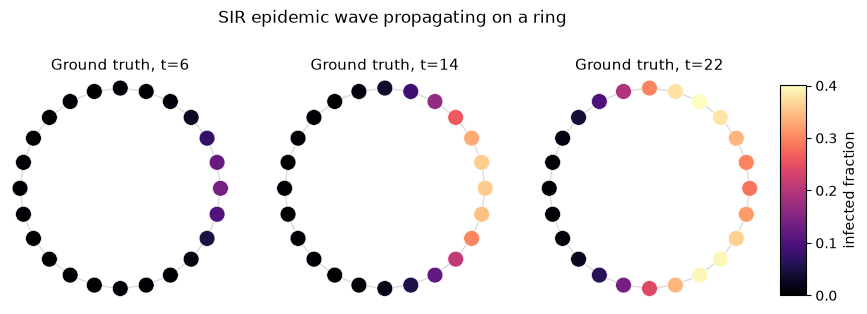

In [3]:
truth_times = [6, 14, 22]
infected_idx = 1
truth_values = [data_sequence[t].x[:, infected_idx].numpy() for t in truth_times]
vmin = 0.0
vmax = max(v.max() for v in truth_values)

fig, axes = plt.subplots(1, len(truth_times), figsize=(3.4 * len(truth_times), 3.4))
scatter_ref = None
for ax, t, values in zip(axes, truth_times, truth_values, strict=True):
    scatter_ref = plot_ring_field(
        ax,
        values,
        RING_POS,
        title=f"Ground truth, t={t}",
        vmin=vmin,
        vmax=vmax,
    )

fig.suptitle("SIR epidemic wave propagating on a ring", y=1.02, fontsize=12)
fig.subplots_adjust(right=0.86)
if scatter_ref is not None:
    cax = fig.add_axes([0.88, 0.18, 0.025, 0.62])
    fig.colorbar(scatter_ref, cax=cax, label="infected fraction")
plt.show()

## Training configuration

The model below uses hyperparameters tuned for **accurate multi-step rollout** on this
ring epidemic (120 epochs interactively). Key choices:

- **3-layer GCN** encoder/decoder (`48` channels) — deeper than the default 2-layer stack.
- **Loss ramp** — start with reconstruction only, then ramp forward, backward, and rollout
  weights so early training stays stable.
- **Rollout horizon** (`12` steps) aligned with the 8-step evaluation window.
- **Strong rollout weight** (`1.5`) and **gradient clipping** for stable late-step forecasts.

In [4]:
IN_CHANNELS = 3
HIDDEN = 48
LATENT = 48
NUM_LAYERS = 3
EPOCHS = 50 if os.environ.get("PYTEST_CURRENT_TEST") else 120
FORECAST_START = 14
PREDICT_STEPS = 8
ROLLOUT_HORIZON = 12
LR = 1e-3
RAMP_EPOCHS = 25 if os.environ.get("PYTEST_CURRENT_TEST") else 40

encoder = GNNEncoder(IN_CHANNELS, HIDDEN, LATENT, num_layers=NUM_LAYERS)
decoder = GNNDecoder(LATENT, HIDDEN, IN_CHANNELS, num_layers=NUM_LAYERS)
model = GraphKoopmanModel(
    encoder=encoder,
    decoder=decoder,
    latent_dim=LATENT,
    time_step=1.0,
)

recon_only = LossWeights(reconstruction=1.0, forward=0.0, backward=0.0, rollout=0.0)
rollout_focus = LossWeights(reconstruction=1.0, forward=0.5, backward=0.1, rollout=1.5)
loss_schedule = linear_ramp_loss_weights(recon_only, rollout_focus, ramp_epochs=RAMP_EPOCHS)

torch.manual_seed(0)
history = model.fit(
    data_sequence,
    epochs=EPOCHS,
    lr=LR,
    loss_weight_schedule=loss_schedule,
    rollout_horizon=ROLLOUT_HORIZON,
    max_grad_norm=1.0,
)
print(f"Epochs: {EPOCHS}")
print(f"Final loss: {history.loss[-1]:.6f}")

Epochs: 120
Final loss: 0.007253


## Truth vs Koopman forecast

We roll out from timestep **`FORECAST_START`** when the infection front is already
visible on the ring. Decoder outputs are projected back to the S/I/R simplex before
scoring and plotting.

The composite figure below shows matched truth/forecast snapshots and a small inset of
the learned Koopman eigenvalues. Modes near the unit circle carry slow epidemic dynamics.

In [5]:
initial_graph = data_sequence[FORECAST_START]
future_graphs = model.predict(initial_graph, steps=PREDICT_STEPS)
ground_truth = data_sequence[FORECAST_START + 1 : FORECAST_START + 1 + PREDICT_STEPS]

projected_graphs = [
    Data(x=project_to_simplex(pred.x), edge_index=pred.edge_index)
    for pred in future_graphs
]

mse = torch.mean(
    torch.stack(
        [
            torch.mean((pred.x - truth.x) ** 2)
            for pred, truth in zip(projected_graphs, ground_truth, strict=True)
        ]
    )
)
print(f"Rollout MSE from t={FORECAST_START} ({PREDICT_STEPS} steps): {mse.item():.6f}")
print(
    f"Mean infected fraction at forecast origin (t={FORECAST_START}): "
    f"{initial_graph.x[:, infected_idx].mean().item():.4f}"
)

Rollout MSE from t=14 (8 steps): 0.003233
Mean infected fraction at forecast origin (t=14): 0.1106


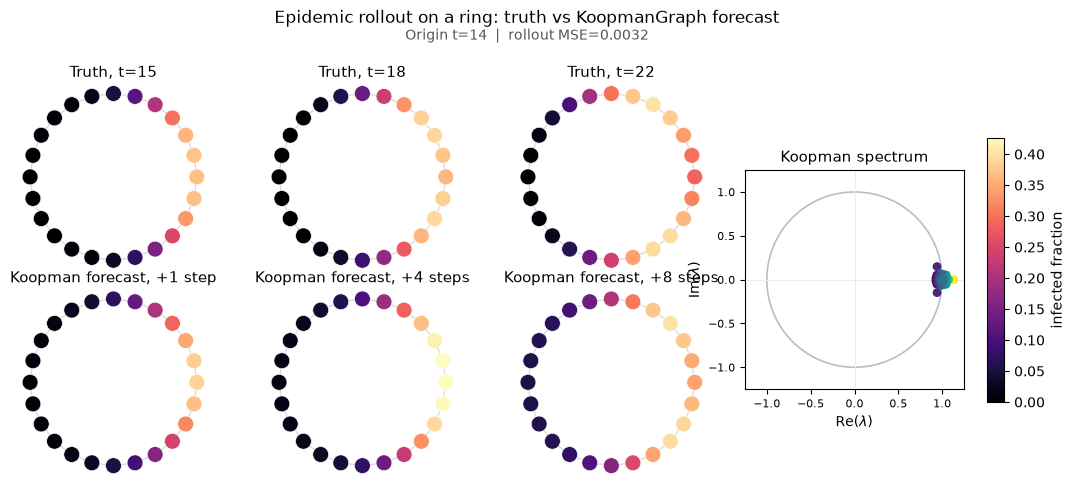

In [6]:
panel_steps = [1, 4, 8]
panel_steps = [s for s in panel_steps if s <= PREDICT_STEPS]

all_i = []
for step in panel_steps:
    idx = step - 1
    all_i.append(ground_truth[idx].x[:, infected_idx].numpy())
    all_i.append(projected_graphs[idx].x[:, infected_idx].numpy())
vmin = 0.0
vmax = max(values.max() for values in all_i)

fig = plt.figure(figsize=(11.5, 4.8))
gs = GridSpec(2, len(panel_steps) + 1, width_ratios=[1.0] * len(panel_steps) + [0.95], wspace=0.08, hspace=0.12)

scatter_ref = None
for col, step in enumerate(panel_steps):
    idx = step - 1
    truth_vals = ground_truth[idx].x[:, infected_idx].numpy()
    pred_vals = projected_graphs[idx].x[:, infected_idx].numpy()

    ax_truth = fig.add_subplot(gs[0, col])
    scatter_ref = plot_ring_field(
        ax_truth,
        truth_vals,
        RING_POS,
        title=f"Truth, t={FORECAST_START + step}",
        vmin=vmin,
        vmax=vmax,
    )

    ax_pred = fig.add_subplot(gs[1, col])
    plot_ring_field(
        ax_pred,
        pred_vals,
        RING_POS,
        title=f"Koopman forecast, +{step} step{'s' if step != 1 else ''}",
        vmin=vmin,
        vmax=vmax,
    )

ax_spec = fig.add_subplot(gs[:, -1])
K = model.koopman.K.detach().cpu()
plot_koopman_spectrum(ax_spec, K)

fig.text(0.5, 0.99, "Epidemic rollout on a ring: truth vs KoopmanGraph forecast", ha="center", fontsize=12)
fig.text(0.5, 0.955, f"Origin t={FORECAST_START}  |  rollout MSE={mse.item():.4f}", ha="center", fontsize=10, color="#555555")

fig.subplots_adjust(top=0.86, bottom=0.05, left=0.04, right=0.88)
if scatter_ref is not None:
    cax = fig.add_axes([0.90, 0.20, 0.015, 0.55])
    cbar = fig.colorbar(scatter_ref, cax=cax)
    cbar.set_label("infected fraction")

plt.show()

## Takeaways

- A ring graph turns epidemic spread into an intuitive **traveling wave** on a circle.
- KoopmanGraph learns shared latent dynamics and rolls the wave forward from a single
  conditioning snapshot.
- Matching color scales across panels makes spatial errors easy to spot at a glance.
- The Koopman spectrum summarizes stability: persistent epidemic modes tend to sit near
  the unit circle, while fast transient modes decay inside it.
- Optional simplex projection keeps decoded S/I/R fractions physically interpretable.

Related notebooks: `01_synthetic_graph.ipynb` (benchmark workflow),
`07_koopman_spectrum.ipynb` (spectrum deep dive), `09_topology_ablation.ipynb` (structure sensitivity).